In [1]:
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

### *Bit-Flip Code*

In [2]:
q_reg_b = QuantumRegister(3)
ancilla_reg_b = AncillaRegister(2)
c_reg_b = ClassicalRegister(2)
qc_b = QuantumCircuit(q_reg_b, ancilla_reg_b, c_reg_b)

qc_b.cx(q_reg_b[0], q_reg_b[1])
qc_b.cx(q_reg_b[0], q_reg_b[2])
qc_b.barrier()

# (qc_b.x(q_reg_b[2]) -> injection of a bit-flip error can be done here)
qc_b.cx(q_reg_b[0], ancilla_reg_b[0])
qc_b.cx(q_reg_b[1], ancilla_reg_b[0])
qc_b.cx(q_reg_b[1], ancilla_reg_b[1])
qc_b.cx(q_reg_b[2], ancilla_reg_b[1])

qc_b.measure(ancilla_reg_b, c_reg_b)

with qc_b.if_test((c_reg_b, 1)):
    qc_b.x(q_reg_b[0])
with qc_b.if_test((c_reg_b, 2)):
    qc_b.x(q_reg_b[2])
with qc_b.if_test((c_reg_b, 3)):
    qc_b.x(q_reg_b[1])

sim = AerSimulator()
t_qc_b = transpile(qc_b, sim)
counts = sim.run(t_qc_b, shots=1024).result().get_counts()

print(counts)

{'00': 1024}


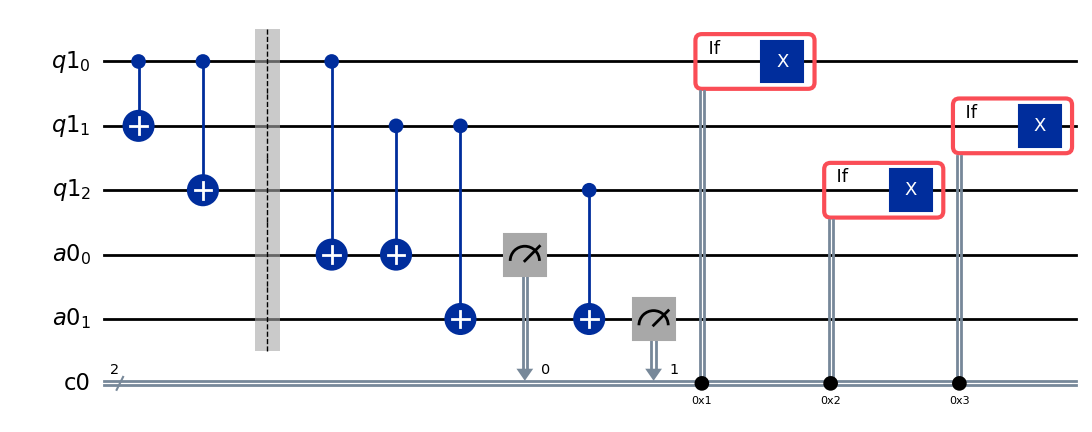

In [3]:
qc_b.draw("mpl")

### *Phase-Flip Code*

In [4]:
q_reg_p = QuantumRegister(3)
ancilla_reg_p = AncillaRegister(2)
c_reg_p = ClassicalRegister(2)
qc_p = QuantumCircuit(q_reg_p, ancilla_reg_p, c_reg_p)

qc_p.cx(q_reg_p[0], q_reg_p[1])
qc_p.cx(q_reg_p[0], q_reg_p[2])
qc_p.barrier()

qc_p.h([q_reg_p[0], q_reg_p[1], q_reg_p[2]])

qc_p.z(q_reg_p[0]) 
qc_p.barrier()

qc_p.h([q_reg_p[0], q_reg_p[1], q_reg_p[2]])
qc_p.cx(q_reg_p[0], ancilla_reg_p[0])
qc_p.cx(q_reg_p[1], ancilla_reg_p[0])
qc_p.cx(q_reg_p[1], ancilla_reg_p[1])
qc_p.cx(q_reg_p[2], ancilla_reg_p[1])
qc_p.h([q_reg_p[0], q_reg_p[1], q_reg_p[2]])

qc_p.measure(ancilla_reg_p, c_reg_p)

with qc_p.if_test((c_reg_p, 1)):
    qc_p.z(q_reg_p[0])
with qc_p.if_test((c_reg_p, 2)):
    qc_p.z(q_reg_p[2])
with qc_p.if_test((c_reg_p, 3)):
    qc_p.z(q_reg_p[1])

sim = AerSimulator()
t_qc_p = transpile(qc_p, sim)
counts = sim.run(t_qc_p, shots=1024).result().get_counts()

print(counts)

{'01': 1024}


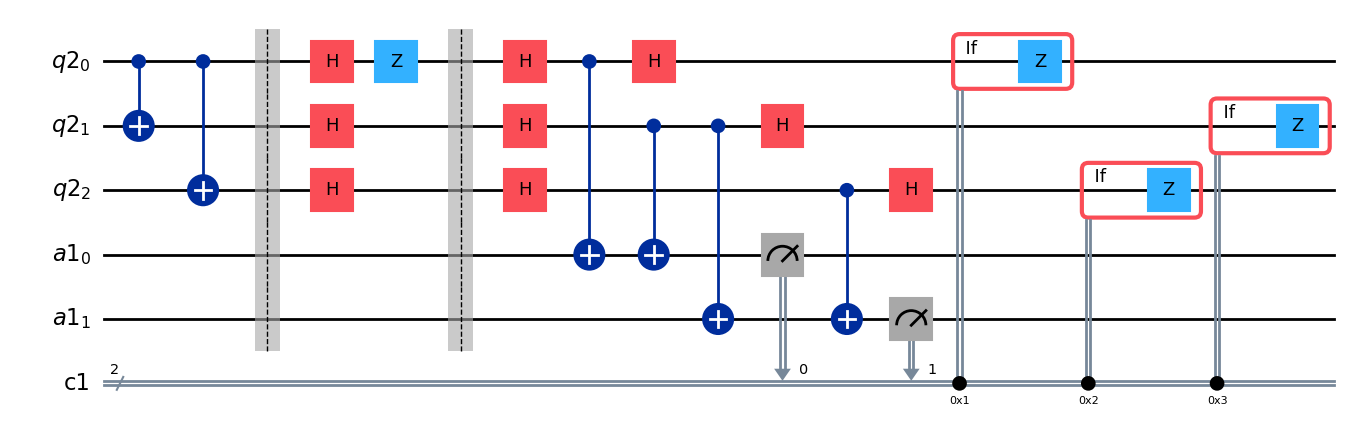

In [5]:
qc_p.draw('mpl')

#### **Implementation of Shor's 9 qubit code for error detection and correction**

In [19]:
data_reg = QuantumRegister(9, 'data')
ancilla_reg = AncillaRegister(8, 'ancilla')
c_reg = ClassicalRegister(1, 'meas')
qc = QuantumCircuit(data_reg, ancilla_reg, c_reg)

qc.rx(1.23,data_reg[0])
qc.barrier()

#Encoding outer code
qc.cx(data_reg[0],data_reg[3])
qc.cx(data_reg[0],data_reg[6])
qc.h([0,3,6])
qc.barrier()

#Encoding inner code
qc.cx(data_reg[0],data_reg[1])
qc.cx(data_reg[0],data_reg[2])
qc.cx(data_reg[3],data_reg[4])
qc.cx(data_reg[3],data_reg[5])
qc.cx(data_reg[6],data_reg[7])
qc.cx(data_reg[6],data_reg[8])
qc.barrier()

# adding error
qc.x(data_reg[0])
qc.z(data_reg[5])

# detecting x error

#block - 1
qc.cx(data_reg[0],ancilla_reg[0])
qc.cx(data_reg[1],ancilla_reg[0])
qc.cx(data_reg[1],ancilla_reg[1])
qc.cx(data_reg[2],ancilla_reg[1])

#block - 2
qc.cx(data_reg[3],ancilla_reg[2])
qc.cx(data_reg[4],ancilla_reg[2])
qc.cx(data_reg[4],ancilla_reg[3])
qc.cx(data_reg[5],ancilla_reg[3])

#block - 3
qc.cx(data_reg[6],ancilla_reg[4])
qc.cx(data_reg[7],ancilla_reg[4])
qc.cx(data_reg[7],ancilla_reg[5])
qc.cx(data_reg[8],ancilla_reg[5])

qc.barrier()

#correct x error

# block - 1
qc.ccx(ancilla_reg[0],ancilla_reg[1],data_reg[1])
qc.x(ancilla_reg[1])
qc.ccx(ancilla_reg[0],ancilla_reg[1],data_reg[0])
qc.x(ancilla_reg[1])
qc.x(ancilla_reg[0])
qc.ccx(ancilla_reg[0],ancilla_reg[1],data_reg[2])
qc.x(ancilla_reg[0])

# block - 2
qc.ccx(ancilla_reg[2],ancilla_reg[3],data_reg[4])
qc.x(ancilla_reg[3])
qc.ccx(ancilla_reg[2],ancilla_reg[3],data_reg[3])
qc.x(ancilla_reg[3])
qc.x(ancilla_reg[2])
qc.ccx(ancilla_reg[2],ancilla_reg[3],data_reg[5])
qc.x(ancilla_reg[2])

# block - 3
qc.ccx(ancilla_reg[4], ancilla_reg[5], data_reg[7])
qc.x(ancilla_reg[5])
qc.ccx(ancilla_reg[4], ancilla_reg[5], data_reg[6])
qc.x(ancilla_reg[5])
qc.x(ancilla_reg[4])
qc.ccx(ancilla_reg[4], ancilla_reg[5], data_reg[8])
qc.x(ancilla_reg[4])
qc.barrier()


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(9, 'data'), 0), Qubit(QuantumRegister(9, 'data'), 1), Qubit(QuantumRegister(9, 'data'), 2), Qubit(QuantumRegister(9, 'data'), 3), Qubit(QuantumRegister(9, 'data'), 4), Qubit(QuantumRegister(9, 'data'), 5), Qubit(QuantumRegister(9, 'data'), 6), Qubit(QuantumRegister(9, 'data'), 7), Qubit(QuantumRegister(9, 'data'), 8), AncillaQubit(AncillaRegister(8, 'ancilla'), 0), AncillaQubit(AncillaRegister(8, 'ancilla'), 1), AncillaQubit(AncillaRegister(8, 'ancilla'), 2), AncillaQubit(AncillaRegister(8, 'ancilla'), 3), AncillaQubit(AncillaRegister(8, 'ancilla'), 4), AncillaQubit(AncillaRegister(8, 'ancilla'), 5), AncillaQubit(AncillaRegister(8, 'ancilla'), 6), AncillaQubit(AncillaRegister(8, 'ancilla'), 7)), clbits=())

In [20]:
qc.h(data_reg) #z error changed into bit flip error HZH = X

# detection of phase flip
qc.cx(data_reg[0],ancilla_reg[6])
qc.cx(data_reg[1],ancilla_reg[6])
qc.cx(data_reg[2],ancilla_reg[6])
qc.cx(data_reg[3],ancilla_reg[6])
qc.cx(data_reg[4],ancilla_reg[6])
qc.cx(data_reg[5],ancilla_reg[6])

qc.cx(data_reg[3], ancilla_reg[7])
qc.cx(data_reg[4], ancilla_reg[7])
qc.cx(data_reg[5], ancilla_reg[7])
qc.cx(data_reg[6], ancilla_reg[7])
qc.cx(data_reg[7], ancilla_reg[7])
qc.cx(data_reg[8], ancilla_reg[7])

qc.h(data_reg)
qc.barrier()

#correction of phase flip, but using x flip as it is converted to bit flip
qc.ccx(ancilla_reg[6], ancilla_reg[7], data_reg[3]) # Block 2 flipped
qc.x(ancilla_reg[7])
qc.ccx(ancilla_reg[6], ancilla_reg[7], data_reg[0]) # Block 1 flipped
qc.x(ancilla_reg[7])
qc.x(ancilla_reg[6])
qc.ccx(ancilla_reg[6], ancilla_reg[7], data_reg[6]) # Block 3 flipped
qc.x(ancilla_reg[6])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(9, 'data'), 0), Qubit(QuantumRegister(9, 'data'), 1), Qubit(QuantumRegister(9, 'data'), 2), Qubit(QuantumRegister(9, 'data'), 3), Qubit(QuantumRegister(9, 'data'), 4), Qubit(QuantumRegister(9, 'data'), 5), Qubit(QuantumRegister(9, 'data'), 6), Qubit(QuantumRegister(9, 'data'), 7), Qubit(QuantumRegister(9, 'data'), 8), AncillaQubit(AncillaRegister(8, 'ancilla'), 0), AncillaQubit(AncillaRegister(8, 'ancilla'), 1), AncillaQubit(AncillaRegister(8, 'ancilla'), 2), AncillaQubit(AncillaRegister(8, 'ancilla'), 3), AncillaQubit(AncillaRegister(8, 'ancilla'), 4), AncillaQubit(AncillaRegister(8, 'ancilla'), 5), AncillaQubit(AncillaRegister(8, 'ancilla'), 6), AncillaQubit(AncillaRegister(8, 'ancilla'), 7)), clbits=())

In [21]:

qc.cx(data_reg[6], data_reg[7]); qc.cx(data_reg[6], data_reg[8])
qc.cx(data_reg[3], data_reg[4]); qc.cx(data_reg[3], data_reg[5])
qc.cx(data_reg[0], data_reg[1]); qc.cx(data_reg[0], data_reg[2])

qc.h([data_reg[0], data_reg[3], data_reg[6]])
qc.cx(data_reg[0], data_reg[6])
qc.cx(data_reg[0], data_reg[3])
qc.barrier()

qc.measure(data_reg[0], c_reg[0])

sim = AerSimulator()
transpiled_circuit = transpile(qc, sim)
counts = sim.run(transpiled_circuit, shots=1024).result().get_counts()

print("Measurement of Logical Qubit:", counts)

Measurement of Logical Qubit: {'0': 660, '1': 364}


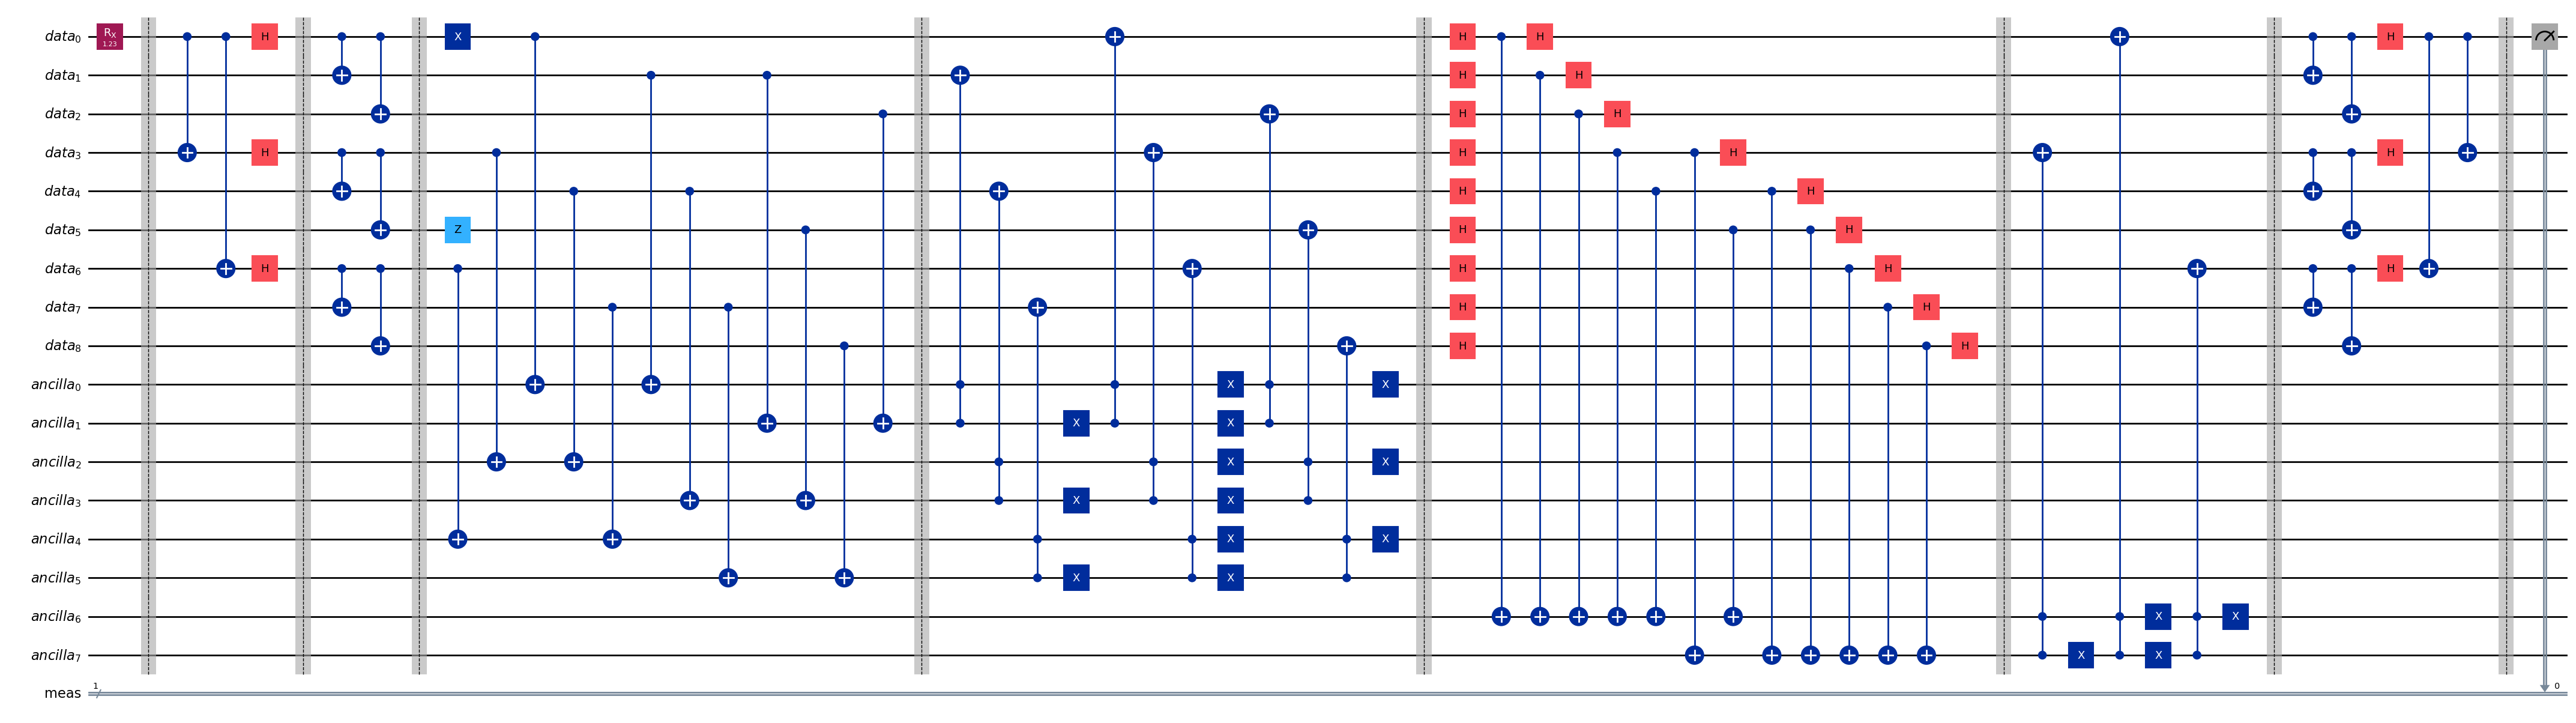

In [24]:
qc.draw('mpl',fold = 80)